<a href="https://colab.research.google.com/github/R-zin/Custom-Cubicasa-Parser/blob/main/Custom-Cubicasa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import torch
import torchvision.models as models
import torch.nn as nn
import timm


In [16]:




class Encoder(nn.Module):
    """
    Shared feature extractor. Uses timm so swapping backbones is a one-line config
    change (resnet50, efficientnet_b4, convnext_tiny, etc.) — same pattern you've
    used with timm for transfer learning already.

    Returns a list of multi-scale feature maps for the FPN decoder.
    """

    def __init__(self, backbone: str = "resnet50", pretrained: bool = True):
        super().__init__()
        self.body = timm.create_model(
            backbone, pretrained=pretrained, features_only=True,
            out_indices=(1, 2, 3, 4),
        )
        self.out_channels = self.body.feature_info.channels()

    def forward(self, x: torch.Tensor) -> list[torch.Tensor]:
        return self.body(x)


class FPNDecoder(nn.Module):
    """Top-down feature pyramid decoder with lateral connections and SE
    (Squeeze-Excitation) channel attention at each lateral, producing a single
    fused feature map at 1/4 input resolution.

    The SE blocks are the main addition over a plain FPN here: room features
    (large, low-frequency, need big receptive field) and icon features (small,
    high-frequency, need fine detail) compete for the same fused channels —
    SE lets the network learn to weight channels differently per input rather
    than averaging everything together uniformly.
    """

    def __init__(self, in_channels: list[int], out_channels: int = 128):
        super().__init__()

        self.lateral_convs = nn.ModuleList([
            nn.Conv2d(c, out_channels, kernel_size=1) for c in in_channels
        ])
        self.se_blocks = nn.ModuleList([
            SEBlock(out_channels) for _ in in_channels
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            for _ in in_channels
        ])

    def forward(self, features: list[torch.Tensor]) -> torch.Tensor:
        laterals = [
            se(conv(f)) for conv, se, f in zip(self.lateral_convs, self.se_blocks, features)
        ]

        # top-down pathway: coarsest -> finest
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = nn.functional.interpolate(
                laterals[i], size=laterals[i - 1].shape[-2:], mode="bilinear", align_corners=False
            )
            laterals[i - 1] = laterals[i - 1] + upsampled

        fused = self.smooth_convs[0](laterals[0])
        # upsample fused map back to 1/4 input resolution for the task head
        fused = nn.functional.interpolate(fused, scale_factor=2, mode="bilinear", align_corners=False)
        return fused


In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation channel attention. Cheap (~2*C*C/r params) way to let
    the network recalibrate which channels matter before the final task split —
    useful here specifically because room features (large, low-frequency) and
    icon features (small, high-frequency) want different channels emphasized,
    and CubiCasa5k's own encoder-decoder has no mechanism for that beyond skip
    connections.
    """

    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class PixelShuffleUpsample(nn.Module):
    """
    Sub-pixel convolution upsample (2x per block). Two of these chained give the
    4x upsample the original repo does with a single stride-4 ConvTranspose2d —
    PixelShuffle avoids the checkerboard artifacts that stride>1 transposed
    convolutions are well known to introduce.
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * 4, kernel_size=3, padding=1)
        self.shuffle = nn.PixelShuffle(upscale_factor=2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.shuffle(self.conv(x))


class JointMultiTaskHead(nn.Module):
    """
    Single shared trunk producing ALL task channels at once, then sliced —
    matching CubiCasa5k's own design (their `conv4_` + `upsample` + implicit
    channel split [21, 12, 11]) rather than three independent head networks.
    This is intentionally *hard* parameter sharing: it forces the backbone to
    learn representations useful to all three tasks simultaneously, rather
    than letting each head specialize away from what the others need.

    Channel ordering matches the original repo exactly: heatmaps first,
    then room classes, then icon classes — so if you ever want to load their
    pretrained `model_best_val_loss_var.pkl` as a starting point, the output
    layout lines up.
    """

    def __init__(
        self,
        in_channels: int,
        num_heatmap_channels: int = 21,
        num_room_classes: int = 12,
        num_icon_classes: int = 11,
        hidden: int = 128,
    ):
        super().__init__()
        self.num_heatmap_channels = num_heatmap_channels
        self.num_room_classes = num_room_classes
        self.num_icon_classes = num_icon_classes
        total_channels = num_heatmap_channels + num_room_classes + num_icon_classes  # = 44

        self.trunk = nn.Sequential(
            _conv_block(in_channels, hidden),
            SEBlock(hidden),
            _conv_block(hidden, hidden),
        )
        # Two 2x sub-pixel upsamples = 4x total, matching the original's
        # single stride-4 ConvTranspose2d but without checkerboard artifacts.
        self.up1 = PixelShuffleUpsample(hidden, hidden)
        self.up2 = PixelShuffleUpsample(hidden, hidden)
        self.final_conv = nn.Conv2d(hidden, total_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, out_size: tuple[int, int]) -> dict:
        x = self.trunk(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.final_conv(x)
        # Safety net: PixelShuffle's fixed 4x factor won't always land exactly
        # on out_size depending on input dims, so snap to the exact target size.
        if x.shape[-2:] != out_size:
            x = F.interpolate(x, size=out_size, mode="bilinear", align_corners=False)

        h = self.num_heatmap_channels
        r = self.num_room_classes
        heatmap_logits = x[:, :h]
        room_logits = x[:, h:h + r]
        icon_logits = x[:, h + r:]

        return {
            "room_logits": room_logits,
            "icon_logits": icon_logits,
            # Sigmoid, not softmax: multiple junction types can be legitimately
            # active at the same pixel (e.g. a wall corner is simultaneously
            # near an opening-corner and an icon-corner) — matches the
            # original repo's activation choice for this head.
            "heatmaps": torch.sigmoid(heatmap_logits),
        }


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class SEBlock(nn.Module):
    """
    Squeeze-and-Excitation channel attention. Cheap (~2*C*C/r params) way to let
    the network recalibrate which channels matter before the final task split —
    useful here specifically because room features (large, low-frequency) and
    icon features (small, high-frequency) want different channels emphasized,
    and CubiCasa5k's own encoder-decoder has no mechanism for that beyond skip
    connections.
    """

    def __init__(self, channels: int, reduction: int = 8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.shape
        scale = self.pool(x).view(b, c)
        scale = self.fc(scale).view(b, c, 1, 1)
        return x * scale


class PixelShuffleUpsample(nn.Module):
    """
    Sub-pixel convolution upsample (2x per block). Two of these chained give the
    4x upsample the original repo does with a single stride-4 ConvTranspose2d —
    PixelShuffle avoids the checkerboard artifacts that stride>1 transposed
    convolutions are well known to introduce.
    """

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * 4, kernel_size=3, padding=1)
        self.shuffle = nn.PixelShuffle(upscale_factor=2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.shuffle(self.conv(x))


class JointMultiTaskHead(nn.Module):
    """
    Single shared trunk producing ALL task channels at once, then sliced —
    matching CubiCasa5k's own design (their `conv4_` + `upsample` + implicit
    channel split [21, 12, 11]) rather than three independent head networks.
    This is intentionally *hard* parameter sharing: it forces the backbone to
    learn representations useful to all three tasks simultaneously, rather
    than letting each head specialize away from what the others need.

    Channel ordering matches the original repo exactly: heatmaps first,
    then room classes, then icon classes — so if you ever want to load their
    pretrained `model_best_val_loss_var.pkl` as a starting point, the output
    layout lines up.
    """

    def __init__(
        self,
        in_channels: int,
        num_heatmap_channels: int = 21,
        num_room_classes: int = 12,
        num_icon_classes: int = 11,
        hidden: int = 128,
    ):
        super().__init__()
        self.num_heatmap_channels = num_heatmap_channels
        self.num_room_classes = num_room_classes
        self.num_icon_classes = num_icon_classes
        total_channels = num_heatmap_channels + num_room_classes + num_icon_classes  # = 44

        self.trunk = nn.Sequential(
            _conv_block(in_channels, hidden),
            SEBlock(hidden),
            _conv_block(hidden, hidden),
        )
        # Two 2x sub-pixel upsamples = 4x total, matching the original's
        # single stride-4 ConvTranspose2d but without checkerboard artifacts.
        self.up1 = PixelShuffleUpsample(hidden, hidden)
        self.up2 = PixelShuffleUpsample(hidden, hidden)
        self.final_conv = nn.Conv2d(hidden, total_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, out_size: tuple[int, int]) -> dict:
        x = self.trunk(x)
        x = self.up1(x)
        x = self.up2(x)
        x = self.final_conv(x)
        # Safety net: PixelShuffle's fixed 4x factor won't always land exactly
        # on out_size depending on input dims, so snap to the exact target size.
        if x.shape[-2:] != out_size:
            x = F.interpolate(x, size=out_size, mode="bilinear", align_corners=False)

        h = self.num_heatmap_channels
        r = self.num_room_classes
        heatmap_logits = x[:, :h]
        room_logits = x[:, h:h + r]
        icon_logits = x[:, h + r:]

        return {
            "room_logits": room_logits,
            "icon_logits": icon_logits,
            # Sigmoid, not softmax: multiple junction types can be legitimately
            # active at the same pixel (e.g. a wall corner is simultaneously
            # near an opening-corner and an icon-corner) — matches the
            # original repo's activation choice for this head.
            "heatmaps": torch.sigmoid(heatmap_logits),
        }


In [19]:
import torch
import torch.nn as nn



class CubiCasaMultiTaskModel(nn.Module):
    def __init__(
        self,
        backbone: str = "resnet50",
        pretrained: bool = True,
        num_room_classes: int = 12,
        num_icon_classes: int = 11,
        num_heatmap_channels: int = 21,
        fpn_channels: int = 128,
    ):
        super().__init__()
        self.encoder = Encoder(backbone=backbone, pretrained=pretrained)
        self.fpn = FPNDecoder(self.encoder.out_channels, out_channels=fpn_channels)

        # Single shared head producing all task channels at once (matching
        # CubiCasa5k's own conv4_ + upsample design) instead of three
        # independent head networks — see heads.py for the reasoning.
        self.head = JointMultiTaskHead(
            in_channels=fpn_channels,
            num_heatmap_channels=num_heatmap_channels,
            num_room_classes=num_room_classes,
            num_icon_classes=num_icon_classes,
        )

    def forward(self, x: torch.Tensor) -> dict:
        out_size = x.shape[-2:]
        features = self.encoder(x)
        fused = self.fpn(features)
        return self.head(fused, out_size)


In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.load("best.pt",device,
                   weights_only=False)


In [21]:
model.values

<function dict.values>

In [22]:
!pip install torchview

In [24]:
import torch
from torchview import draw_graph


checkpoint = torch.load("best.pt", map_location="cpu")

print(checkpoint.keys())
# dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch'])

model = CubiCasaMultiTaskModel()
model.load_state_dict(checkpoint["model_state_dict"])

graph = draw_graph(
    model,
    input_size=(1, 3, 224, 224),
    expand_nested=True
)

graph.visual_graph.render("model_graph", format="png")

dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch'])


'model_graph.png'

In [27]:
import cv2
import matplotlib.pyplot as plt


In [32]:
img = cv2.imread("img14.png")


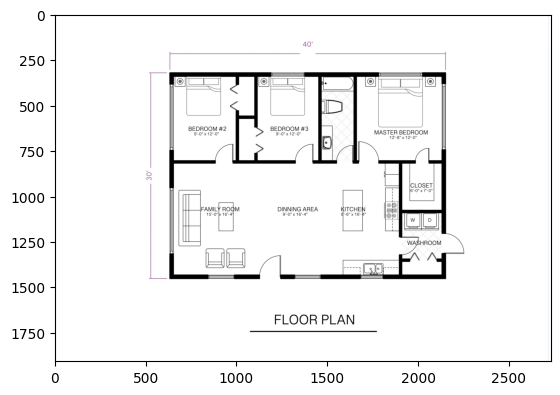

In [33]:
plt.imshow(img)


In [35]:
from torchvision.transforms import v2
def preprocess_image(image):
  transforms = v2.Compose([
      v2.Resize(224, max_size=224),
      v2.Pad(padding=244,fill=0),
      v2.CenterCrop(224)
  ])
  return transforms(image)


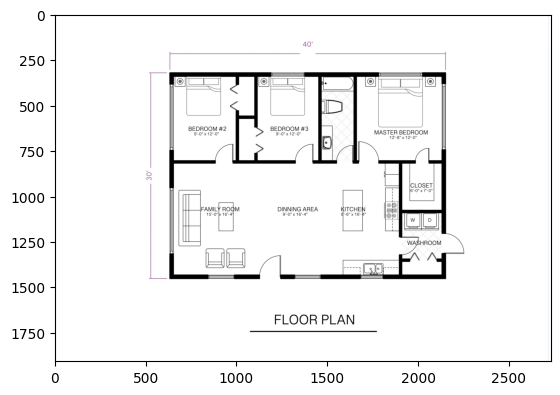

In [36]:
plt.imshow(preprocess_image(img))

In [37]:
x = preprocess_image(img)
model.to(device)